In [1]:
# Cell 1 — install + imports
!pip install torch torchvision pillow matplotlib tqdm --quiet

import os, time, zipfile, requests
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from google.colab import files

# paths
ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)
CONTENT_PATH = ROOT / "content.jpg"
STYLE_PATH = ROOT / "style.jpg"
ZIP_NAME = "output_results.zip"
print("Ready. Output folder:", OUTPUT_DIR)

Ready. Output folder: /content/output


Download failed: https://upload.wikimedia.org/wikipedia/commons/e/ea/The_Starry_Night.jpg
Download failed: https://upload.wikimedia.org/wikipedia/commons/0/0c/Claude_Monet%2C_Impression%2C_soleil_levant.jpg
Download failed: https://upload.wikimedia.org/wikipedia/commons/4/4d/Vincent_van_Gogh_-_Sunflowers_-_VGM_F458.jpg
Generated random style image


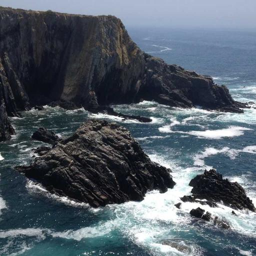

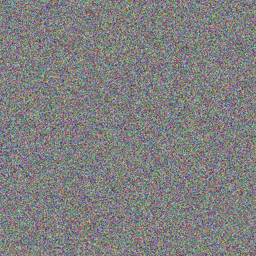

In [5]:
# Cell 2 — download random content + style (robust)

import requests
from PIL import Image
from io import BytesIO

def download_image(url, path):
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()

        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(path)

        print("Downloaded:", path)
        return True

    except Exception as e:
        print("Download failed:", url)
        return False


# CONTENT IMAGE (random)
if not CONTENT_PATH.exists():
    download_image("https://picsum.photos/512", CONTENT_PATH)


# STYLE IMAGE (stable Wikimedia links)
style_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/e/ea/The_Starry_Night.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/0/0c/Claude_Monet%2C_Impression%2C_soleil_levant.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/4/4d/Vincent_van_Gogh_-_Sunflowers_-_VGM_F458.jpg"
]

style_downloaded = False

if not STYLE_PATH.exists():

    for url in style_urls:

        if download_image(url, STYLE_PATH):
            style_downloaded = True
            break


# Final fallback (generate random style if all fail)
if not STYLE_PATH.exists():

    import numpy as np

    random_style = (np.random.rand(512,512,3)*255).astype("uint8")
    Image.fromarray(random_style).save(STYLE_PATH)

    print("Generated random style image")


# Display images
display(Image.open(CONTENT_PATH).resize((256,256)))
display(Image.open(STYLE_PATH).resize((256,256)))

In [6]:
# Cell 3 — GPU + VRAM check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1024**3)
    try:
        print("Free VRAM (GB):", torch.cuda.mem_get_info()[0] / 1024**3)
    except:
        pass

Device: cuda
GPU: Tesla T4
Total VRAM (GB): 14.56317138671875
Free VRAM (GB): 14.46075439453125


In [7]:
# Cell 4 — image transforms & helpers
im_size = 384  # reduce to 256 if OOM on T4
loader = transforms.Compose([
    transforms.Resize(im_size),
    transforms.CenterCrop(im_size),
    transforms.ToTensor()
])
unloader = transforms.ToPILImage()

def load_image(path):
    img = Image.open(path).convert("RGB")
    return loader(img).unsqueeze(0).to(device)

def save_tensor_img(tensor, filename):
    img = tensor.clone().detach().cpu().squeeze(0)
    img = torch.clamp(img, 0, 1)
    pil = unloader(img)
    p = OUTPUT_DIR / filename
    pil.save(p)
    return p

def show_pil(img):
    display(img)

In [8]:
# Cell 5 — load images to tensors
content_img = load_image(str(CONTENT_PATH))
style_img   = load_image(str(STYLE_PATH))
print("content:", content_img.shape, "style:", style_img.shape)

content: torch.Size([1, 3, 384, 384]) style: torch.Size([1, 3, 384, 384])


In [9]:
# Cell 6 — prepare pretrained VGG19 (features) and helpers
vgg = models.vgg19(pretrained=True).features.to(device).eval()
for p in vgg.parameters():
    p.requires_grad = False

content_layers = ['21']                 # conv4_2
style_layers   = ['0','5','10','19','28']  # conv1_1, conv2_1, conv3_1, conv4_1, conv5_1

def get_features(x, model, layers):
    features = {}
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[name] = x
    return features

def gram_matrix(tensor):
    # accepts both 4D (B,C,H,W) and 3D (C,H,W)
    if tensor.dim() == 4:
        b,c,h,w = tensor.size()
        tensor = tensor.view(c, h*w)
    elif tensor.dim() == 3:
        c,h,w = tensor.size()
        tensor = tensor.view(c, h*w)
    gram = torch.mm(tensor, tensor.t())
    return gram / (c * h * w)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 104MB/s] 


In [10]:
# Cell 7 — compute target features, style grams, content features
style_features = get_features(style_img, vgg, style_layers)
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

content_features = get_features(content_img, vgg, content_layers)
print("Prepared style grams and content features.")

Prepared style grams and content features.


In [11]:
# Cell 8 — loss fns and hyperparams
mse = nn.MSELoss()

def compute_content_loss(target_feats, content_feats, content_weight):
    t = target_feats[content_layers[0]]
    c = content_feats[content_layers[0]]
    return content_weight * mse(t, c)

def compute_style_loss(target_feats, style_grams, style_weights, style_weight_scale):
    loss = 0.0
    for layer, w in style_weights.items():
        t_feat = target_feats[layer]
        t_gram = gram_matrix(t_feat)
        s_gram = style_grams[layer]
        loss += w * mse(t_gram, s_gram)
    return style_weight_scale * loss

# hyperparams (you can tune)
content_weight = 1e5
style_weight_scale = 1e10
style_weights = {'0':0.2,'5':0.2,'10':0.2,'19':0.2,'28':0.2}
num_steps = 300
save_interval = 50

In [12]:
# Cell 9 — init target and optimizer
target = content_img.clone().requires_grad_(True).to(device)
optimizer = optim.Adam([target], lr=0.02)
loss_history = []
start_time = time.time()

In [13]:
# Cell 10 — optimization loop (saves intermediates)
run = 0
while run < num_steps:
    optimizer.zero_grad()
    target_clamped = torch.clamp(target, 0, 1)
    target_feats = get_features(target_clamped, vgg, style_layers + content_layers)
    c_loss = compute_content_loss(target_feats, content_features, content_weight)
    s_loss = compute_style_loss(target_feats, style_grams, style_weights, style_weight_scale)
    total_loss = c_loss + s_loss
    total_loss.backward()
    optimizer.step()
    loss_history.append(total_loss.item())
    run += 1
    if run % save_interval == 0 or run == 1 or run == num_steps:
        print(f"Step {run}/{num_steps}  loss: {total_loss.item():.4e}")
        save_tensor_img(torch.clamp(target,0,1), f"stylized_step_{run:04d}.jpg")
end_time = time.time()
print("Optimization done. Time (s):", end_time - start_time)
save_tensor_img(torch.clamp(target,0,1), "stylized_final.jpg")

Step 1/300  loss: 8.5738e+04
Step 50/300  loss: 1.1270e+04
Step 100/300  loss: 8.6573e+03
Step 150/300  loss: 7.9089e+03
Step 200/300  loss: 7.5139e+03
Step 250/300  loss: 7.2621e+03
Step 300/300  loss: 7.0512e+03
Optimization done. Time (s): 21.481101989746094


PosixPath('/content/output/stylized_final.jpg')

Saved evaluation grid: /content/output/evaluation_grid.jpg


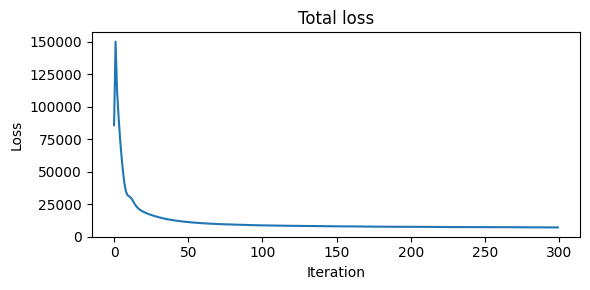

In [14]:
# Cell 11 — evaluation grid and loss plot
final_path = OUTPUT_DIR / "stylized_final.jpg"
final_img = Image.open(final_path).resize((im_size, im_size))
content_pil = Image.open(CONTENT_PATH).resize((im_size, im_size))
style_pil   = Image.open(STYLE_PATH).resize((im_size, im_size))

grid = Image.new('RGB', (im_size*3, im_size))
grid.paste(content_pil, (0,0))
grid.paste(style_pil, (im_size,0))
grid.paste(final_img, (im_size*2,0))
draw = ImageDraw.Draw(grid)
draw.text((8,8), "Content", fill=(255,255,255))
draw.text((im_size+8,8), "Style", fill=(255,255,255))
draw.text((im_size*2+8,8), "Output", fill=(255,255,255))
grid_path = OUTPUT_DIR / "evaluation_grid.jpg"
grid.save(grid_path)
print("Saved evaluation grid:", grid_path)

# loss plot
plt.figure(figsize=(6,3))
plt.plot(loss_history)
plt.title("Total loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve.png")
plt.show()

In [15]:
# Cell 12 — save model state_dict, README
torch.save(vgg.state_dict(), OUTPUT_DIR / "vgg19_features_state_dict.pth")
report = f"""Neural Style Transfer Report
content: {CONTENT_PATH}
style: {STYLE_PATH}
im_size: {im_size}
num_steps: {num_steps}
content_weight: {content_weight}
style_weight_scale: {style_weight_scale}
"""
with open(OUTPUT_DIR / "README.txt", "w") as f:
    f.write(report)
print("Saved model and README to", OUTPUT_DIR)

Saved model and README to /content/output


In [16]:
# Cell 13 — zip outputs and trigger download
with zipfile.ZipFile(ZIP_NAME, "w") as z:
    for f in sorted(OUTPUT_DIR.iterdir()):
        z.write(f, arcname=f.name)
print("Created ZIP:", ZIP_NAME)
files.download(ZIP_NAME)

Created ZIP: output_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>